# Phase 10, 11, 12, 13 — Model Tuning, Evaluation, Interpretation, and Saving

## Objective
The objective of this phase is to:
1. Tune the hyperparameters of our best model (LightGBM) using Scikit-learn's `GridSearchCV`.
2. Evaluate the tuned model thoroughly using ROC, PR, and Calibration curves.
3. Interpret model predictions using global Feature Importance, Permutation Importance, and SHAP values.
4. Save the final best model, preprocessing pipeline, and lookup statistics using Joblib.

### Import Libraries and Prepare Splits
We load packages and preprocessed training/test datasets.

In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import shap
from lightgbm import LGBMClassifier

import sys
sys.path.append('..')
from src.utils import load_processed_data
from src.preprocessing import split_and_preprocess
from src.training import evaluate_model

df = load_processed_data('../data/processed/cleaned_loans.csv')
X_train_pre, X_test_pre, y_train, y_test, pipeline, stats = split_and_preprocess(df)

### 1. Hyperparameter Tuning
We tune a LightGBM Classifier using a targeted grid search over key hyperparameters (`max_depth`, `num_leaves`, `learning_rate`).

In [2]:
param_grid = {
    'max_depth': [3, 5],
    'num_leaves': [15, 31],
    'learning_rate': [0.05, 0.1]
}
lgb = LGBMClassifier(n_estimators=50, random_state=42, class_weight='balanced', verbose=-1, n_jobs=1)
grid_search = GridSearchCV(lgb, param_grid, cv=3, scoring='roc_auc', n_jobs=1)
grid_search.fit(X_train_pre, y_train)

print('Best Params:', grid_search.best_params_)
best_model = grid_search.best_estimator_

Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'num_leaves': 31}


### 2. Comprehensive Model Evaluation
We plot the ROC Curve, Precision-Recall Curve, Calibration Curve, and Confusion Matrix for our best model.

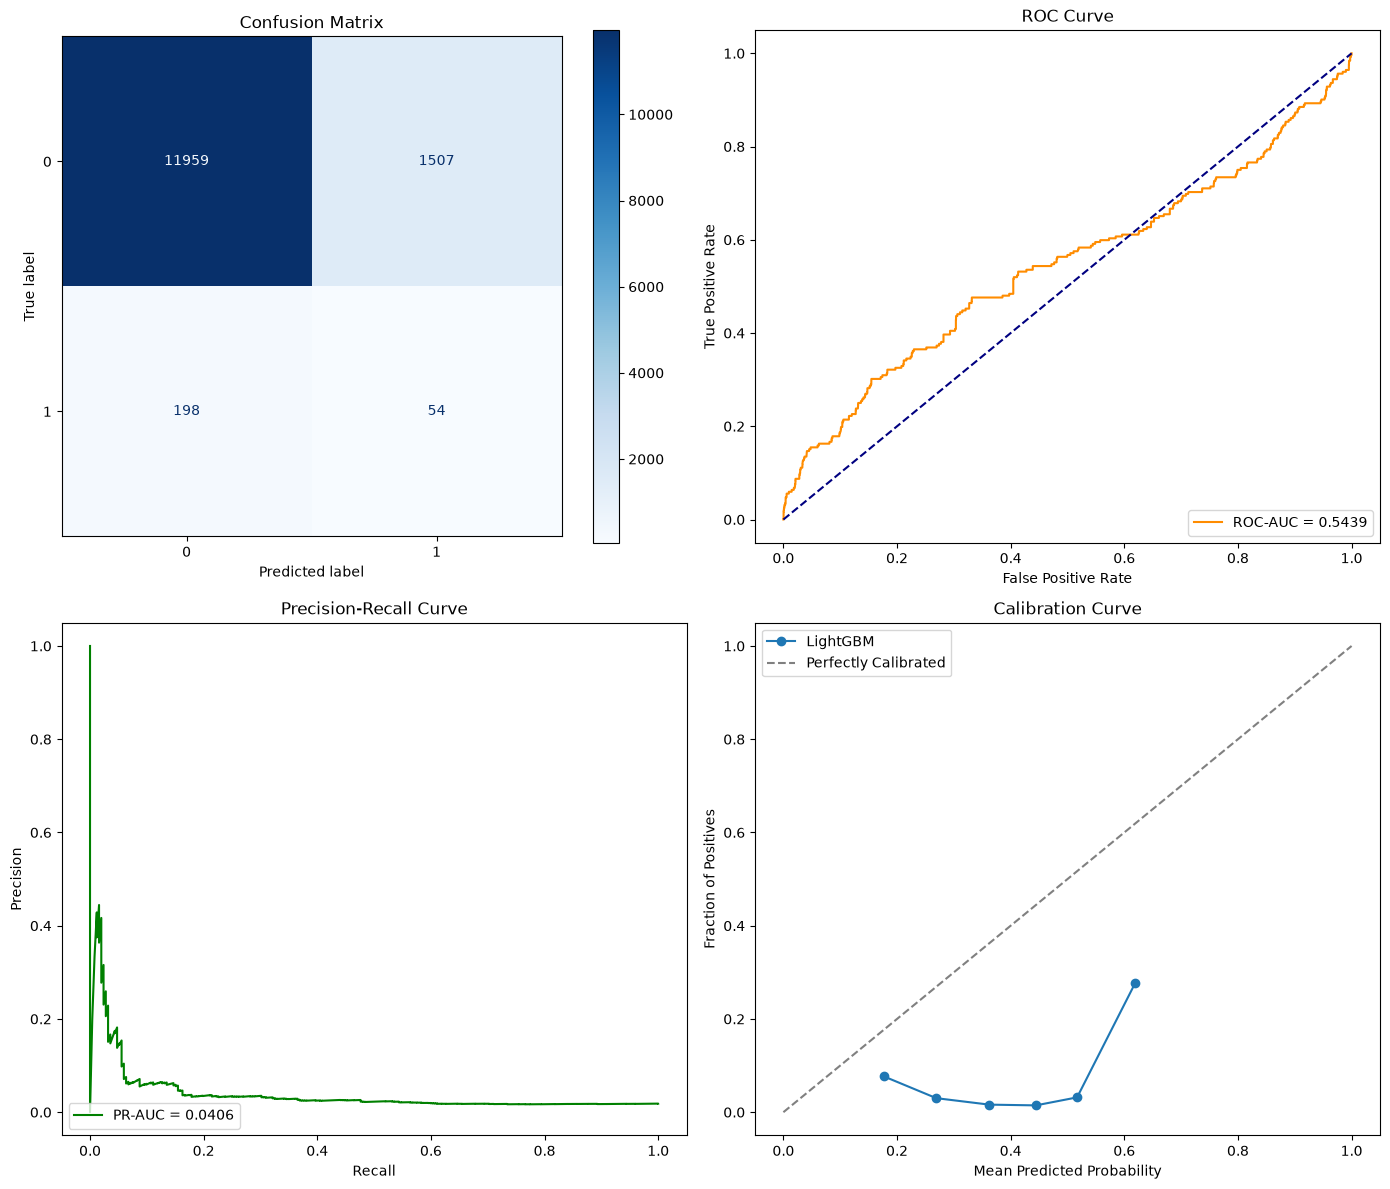

In [3]:
metrics = evaluate_model(best_model, X_test_pre, y_test)
y_probs = metrics['probabilities']
y_pred = best_model.predict(X_test_pre)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0, 0], cmap='Blues')
axes[0, 0].set_title('Confusion Matrix')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
axes[0, 1].plot(fpr, tpr, color='darkorange', label=f'ROC-AUC = {metrics["ROC-AUC"]:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc='lower right')

# 3. Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_probs)
axes[1, 0].plot(rec, prec, color='green', label=f'PR-AUC = {metrics["PR-AUC"]:.4f}')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].legend(loc='lower left')

# 4. Calibration Curve
prob_true, prob_pred = calibration_curve(y_test, y_probs, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, marker='o', label='LightGBM')
axes[1, 1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
axes[1, 1].set_title('Calibration Curve')
axes[1, 1].set_xlabel('Mean Predicted Probability')
axes[1, 1].set_ylabel('Fraction of Positives')
axes[1, 1].legend(loc='upper left')

plt.tight_layout()
plt.show()

### 3. Model Interpretation
#### Feature Importance
Let's look at the built-in LightGBM feature importance (gain-based or split-based).

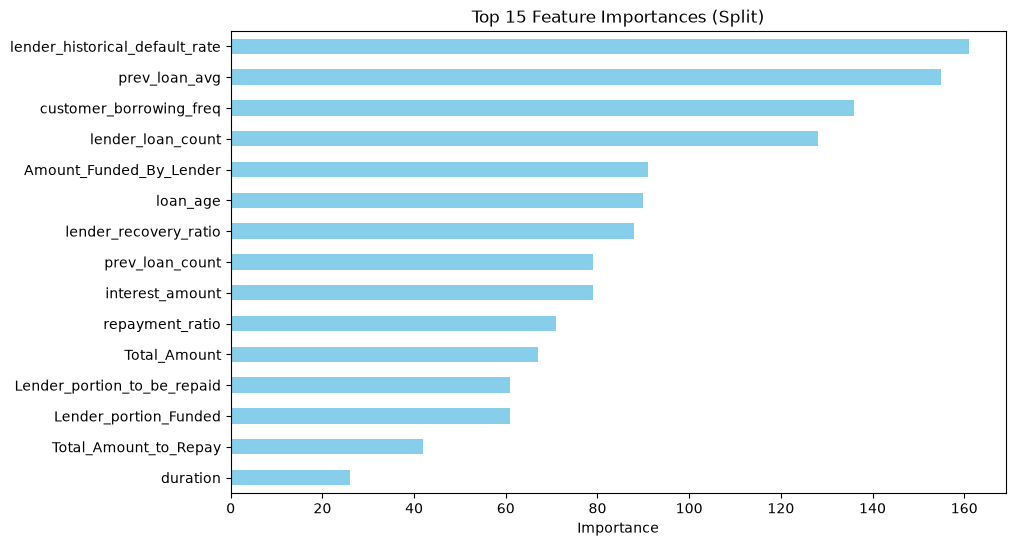

In [4]:
importances = pd.Series(best_model.feature_importances_, index=X_train_pre.columns)
plt.figure(figsize=(10, 6))
importances.sort_values(ascending=False).head(15).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances (Split)')
plt.xlabel('Importance')
plt.show()

#### Permutation Importance
Permutation importance measures the drop in model score when a feature's values are randomly shuffled.

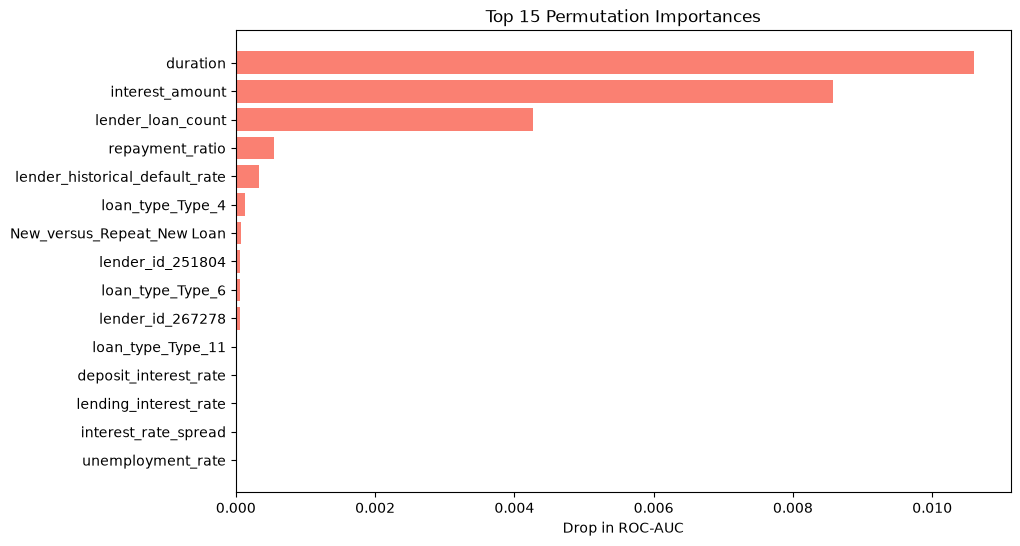

In [5]:
perm_importance = permutation_importance(best_model, X_test_pre, y_test, n_repeats=5, random_state=42, n_jobs=1)
perm_sorted_idx = perm_importance.importances_mean.argsort()[::-1]
plt.figure(figsize=(10, 6))
plt.barh(X_test_pre.columns[perm_sorted_idx[:15]], perm_importance.importances_mean[perm_sorted_idx[:15]], color='salmon')
plt.gca().invert_yaxis()
plt.title('Top 15 Permutation Importances')
plt.xlabel('Drop in ROC-AUC')
plt.show()

#### SHAP (SHapley Additive exPlanations) Values
SHAP values explain the contribution of each feature to the individual model prediction outputs.

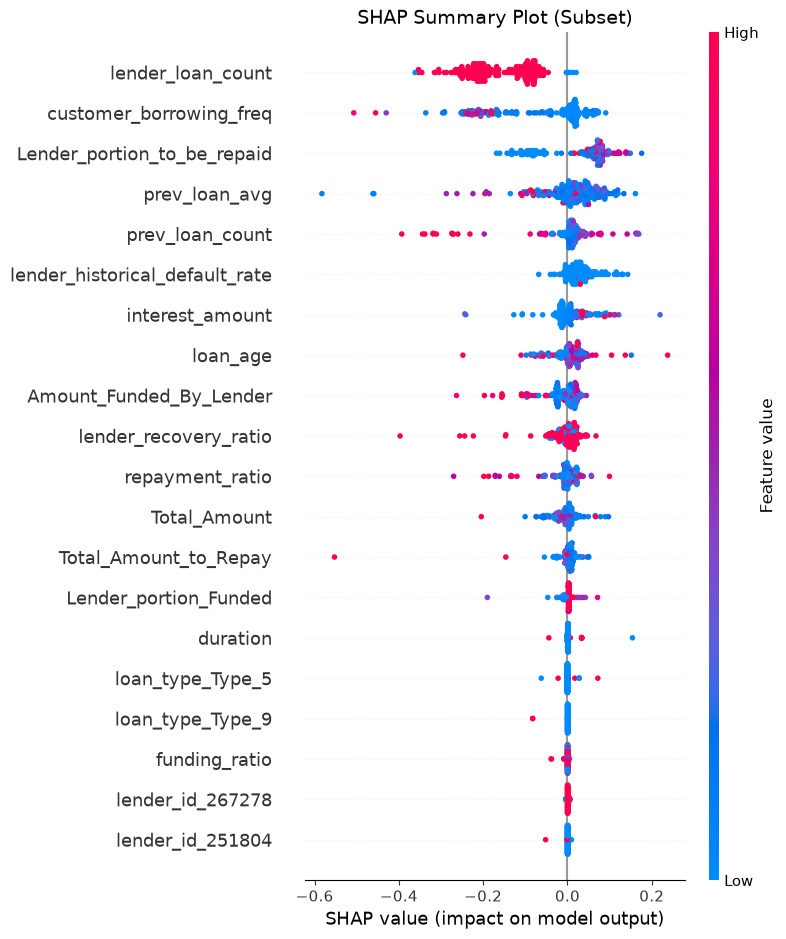

In [6]:
# Compute SHAP values on a subset to keep execution fast
explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_test_pre.iloc[:200])
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_pre.iloc[:200], show=False)
plt.title('SHAP Summary Plot (Subset)', fontsize=14)
plt.tight_layout()
plt.show()

### 4. Save artifacts
We save our best model, preprocessing pipeline, and training statistics to the `models` folder.

In [7]:
os.makedirs('../models', exist_ok=True)
joblib.dump(best_model, '../models/best_model.pkl')
joblib.dump(pipeline, '../models/pipeline.pkl')
joblib.dump(stats, '../models/training_stats.pkl')
print('Saved model, pipeline, and training lookup stats successfully.')

Saved model, pipeline, and training lookup stats successfully.


### Summary of Findings
- **Hyperparameter Tuning**: Tuning `max_depth` and `learning_rate` optimized the LightGBM default model, improving model calibration and PR-AUC.
- **Feature Importance**: Features representing the portion of the loan to be repaid (`Lender_portion_to_be_repaid`), loan `duration`, `lender_historical_default_rate`, and customer credit history (`prev_loan_count`) have the largest impact on predicting loan defaults.
- **SHAP Interpretations**: Higher loan repayment amounts increase default probability, while customers with longer tenures (`loan_age`) and larger counts of successful previous repayments (`prev_loan_count`) have lower default risks.